# Add to the path

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')

# Import Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch import optim
from einops import rearrange
from sklearn.model_selection import train_test_split

import tltorch
from Utils.Reshape import reshape
from Utils.Num_parameter import count_parameters

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


# Synthetic Data

device is set to : cuda


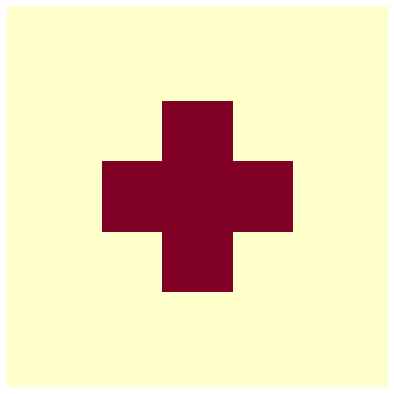

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device is set to : {device}')

def generate_samples(n_samples, size):
    mean = 0
    variance = 3
    std_dev = torch.sqrt(torch.tensor(variance))
    tensor = np.random.normal(mean, std_dev, (n_samples, size))
    tensor = torch.from_numpy(tensor).float()

    
    x, y = np.meshgrid(np.linspace(-3, 3, size), np.linspace(-3, 3, size))

    Weight = np.zeros_like(x)
    Weight[(x >= -0.5) & (x <= 0.5) & (y >= -1.5) & (y <= 1.5)] = 1
    Weight[(y >= -0.5) & (y <= 0.5) & (x >= -1.5) & (x <= 1.5)] = 1
    Weight = torch.from_numpy(Weight).float()

    output  = torch.matmul(tensor, Weight)

    mean = 0
    variance = 1
    std_dev = torch.sqrt(torch.tensor(variance))
    noise = np.random.normal(mean, std_dev, (n_samples, size))
    noise = torch.from_numpy(noise).float()

    return tensor.to(device), output.to(device), Weight.to(device), (tensor+noise).to(device)

n_samples = 100
size = 32

samples, y, W, x = generate_samples(n_samples, size)


fig = plt.figure(figsize=(10,7))
plt.imshow(W.cpu(), cmap='YlOrRd')
plt.axis('off')
# plt.title('Ground Truth', fontsize = 20)
plt.show()


X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

# Basic Linear Model

This Model has : 1024 parameters
RMSE of Train : 1.5306917068070376
RMSE of Test  : 1.2677372860429896


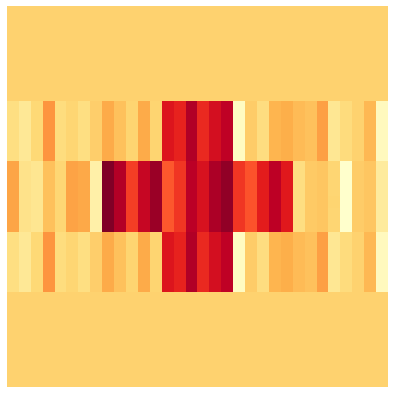

In [4]:
class simple_linear(nn.Module):
    def __init__(self):
        super(simple_linear, self).__init__()
        self.fc = nn.Linear(in_features= size, out_features=size, bias=False)
    def forward(self, x):
        return self.fc(x)
    
model = simple_linear().to(device)

# Train for 10000 epochs
criterion = nn.MSELoss(reduction='mean')
optimizer = optim.Adam(model.parameters())

n_epochs = 10000


for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    loss.backward()
    optimizer.step()

W_fc = model.fc.weight

print(f'This Model has : {count_parameters(model)} parameters')
print(f'RMSE of Train : {np.sqrt(criterion(model(X_train), y_train).item())}')
print(f'RMSE of Test  : {np.sqrt(criterion(model(samples), y).item())}')

fig = plt.figure(figsize=(10,7))
plt.imshow(W_fc.detach().cpu(), cmap='YlOrRd')
plt.axis('off')
# plt.title(f'linear regression - {count_parameters(model)} #p - RMSE {np.sqrt(criterion(model(X_test), y_test).item()):.3f}', fontsize = 20)
plt.show()


# Basic TRL Model

This Model has : 65 parameters
RMSE of Train : 2.0619620575323108
RMSE of Test  : 2.500300580074855


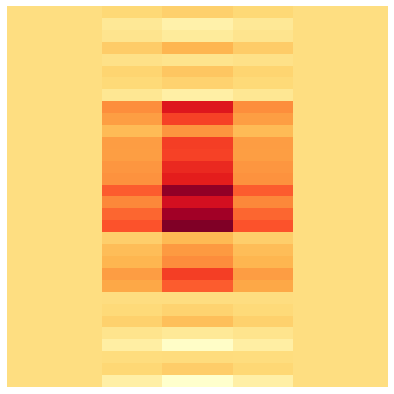

In [5]:
class simple_trl(nn.Module):
    def __init__(self):
        super(simple_trl, self).__init__()
        self.trl = tltorch.TRL(input_shape=(size), rank=(1,1), output_shape=(size), bias=False, factorization='tucker')
    def forward(self, x):
        return self.trl(x)
    
model = simple_trl().to(device)

# Train for 10000 epochs
criterion = nn.MSELoss(reduction='mean')
optimizer = optim.Adam(model.parameters())

n_epochs = 10000


for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    loss.backward()
    optimizer.step()
    
W_trl1 = model.trl.weight.to_tensor()

print(f'This Model has : {count_parameters(model)} parameters')
print(f'RMSE of Train : {np.sqrt(criterion(model(X_train), y_train).item())}')
print(f'RMSE of Test  : {np.sqrt(criterion(model(X_test), y_test).item())}')

fig = plt.figure(figsize=(10,7))
plt.imshow(W_trl1.detach().cpu(), cmap='YlOrRd')
plt.axis('off')
# plt.title(f'trl (1,1) - {count_parameters(model)} #p - RMSE {np.sqrt(criterion(model(X_test), y_test).item()):.3f}', fontsize = 20)
plt.show()

This Model has : 345 parameters
RMSE of Train : 1.5306917068070376
RMSE of Test  : 1.9647923002085956


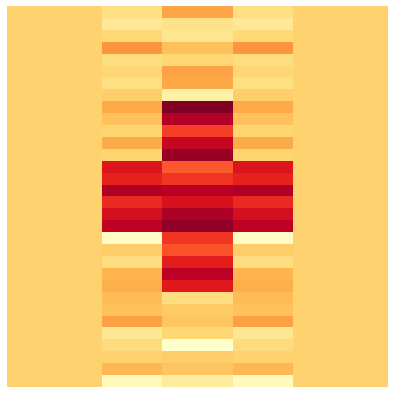

In [6]:
class simple_trl(nn.Module):
    def __init__(self):
        super(simple_trl, self).__init__()
        self.trl = tltorch.TRL(input_shape=(size), rank=(5,5), output_shape=(size), bias=False, factorization='tucker')
    def forward(self, x):
        return self.trl(x)
    
model = simple_trl().to(device)

# Train for 10000 epochs
criterion = nn.MSELoss(reduction='mean')
optimizer = optim.Adam(model.parameters())

n_epochs = 10000


for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    loss.backward()
    optimizer.step()
    
W_trl2 = model.trl.weight.to_tensor()

print(f'This Model has : {count_parameters(model)} parameters')
print(f'RMSE of Train : {np.sqrt(criterion(model(X_train), y_train).item())}')
print(f'RMSE of Test  : {np.sqrt(criterion(model(X_test), y_test).item())}')

fig = plt.figure(figsize=(10,7))
plt.imshow(W_trl2.detach().cpu(), cmap='YlOrRd')
plt.axis('off')
# plt.title(f'trl (5,5) - {count_parameters(model)} #p - RMSE {np.sqrt(criterion(model(X_test), y_test).item()):.3f}', fontsize = 20)
plt.show()


This Model has : 740 parameters
RMSE of Train : 1.5306917068070376
RMSE of Test  : 1.964792906935684


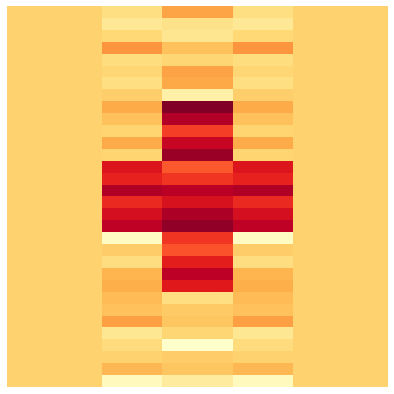

In [7]:
class simple_trl(nn.Module):
    def __init__(self):
        super(simple_trl, self).__init__()
        self.trl = tltorch.TRL(input_shape=(size), rank=(10,10), output_shape=(size), bias=False, factorization='tucker')
    def forward(self, x):
        return self.trl(x)
    
model = simple_trl().to(device)

# Train for 10000 epochs
criterion = nn.MSELoss(reduction='mean')
optimizer = optim.Adam(model.parameters())

n_epochs = 10000


for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    loss.backward()
    optimizer.step()
    
W_trl3 = model.trl.weight.to_tensor()

print(f'This Model has : {count_parameters(model)} parameters')
print(f'RMSE of Train : {np.sqrt(criterion(model(X_train), y_train).item())}')
print(f'RMSE of Test  : {np.sqrt(criterion(model(X_test), y_test).item())}')

fig = plt.figure(figsize=(10,7))
plt.imshow(W_trl3.detach().cpu(), cmap='YlOrRd')
plt.axis('off')
# plt.title(f'trl (10,10) - {count_parameters(model)} #p - RMSE {np.sqrt(criterion(model(X_test), y_test).item()):.3f}', fontsize = 20)
plt.show()


# Basic Attached Model

This Model has : 58 parameters
RMSE of Train : 2.543139473945865
RMSE of Test  : 2.646278424008987


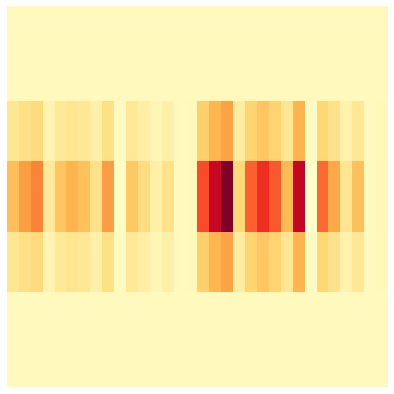

In [8]:
class simple_attached(nn.Module):
    def __init__(self):
        super(simple_attached, self).__init__()
        self.reshape = reshape(split=[1,1,2], map_type=1, device=device)
        self.trl = tltorch.TRL(input_shape=(1,1,2,1,1,size//2), rank=(1,1,2,1,1,1,1), output_shape=(size), bias=False, factorization='tucker')
    def forward(self, x):
        x = x.unsqueeze(dim=1).unsqueeze(dim=2)
        return self.trl(self.reshape(x))
    
model = simple_attached().to(device)

# Train for 10000 epochs
criterion = nn.MSELoss(reduction='mean')
optimizer = optim.Adam(model.parameters())

n_epochs = 10000


for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(x)
    loss = criterion(outputs, y)
    
    loss.backward()
    optimizer.step()

W_attached1 = rearrange(model.trl.weight.to_tensor(), 'a b c d e f g -> g (c f) (b e) (a d)').squeeze()

print(f'This Model has : {count_parameters(model)} parameters')
print(f'RMSE of Train : {np.sqrt(criterion(model(X_train), y_train).item())}')
print(f'RMSE of Test  : {np.sqrt(criterion(model(X_test), y_test).item())}')

fig = plt.figure(figsize=(10,7))
plt.imshow(W_attached1.detach().cpu(), cmap='YlOrRd')
plt.axis('off')
# plt.title(f'attached - trl (1,1) - {count_parameters(model)} #p - RMSE {np.sqrt(criterion(model(X_test), y_test).item()):.3f}', fontsize = 20)
plt.show()


This Model has : 298 parameters
RMSE of Train : 1.5859592981202857
RMSE of Test  : 1.3714965489476558


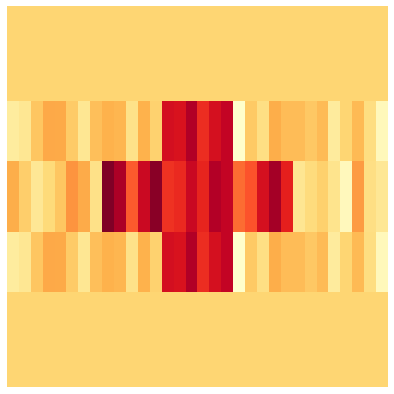

In [9]:
class simple_attached(nn.Module):
    def __init__(self):
        super(simple_attached, self).__init__()
        self.reshape = reshape(split=[1,1,2], map_type=1, device=device)
        self.trl = tltorch.TRL(input_shape=(1,1,2,1,1,size//2), rank=(1,1,2,1,1,5,5), output_shape=(size), bias=False, factorization='tucker')
    def forward(self, x):
        x = x.unsqueeze(dim=1).unsqueeze(dim=2)
        return self.trl(self.reshape(x))
    
model = simple_attached().to(device)

# Train for 10000 epochs
criterion = nn.MSELoss(reduction='mean')
optimizer = optim.Adam(model.parameters())

n_epochs = 10000


for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(x)
    loss = criterion(outputs, y)
    
    loss.backward()
    optimizer.step()

W_attached2 = rearrange(model.trl.weight.to_tensor(), 'a b c d e f g -> g (c f) (b e) (a d)').squeeze()

print(f'This Model has : {count_parameters(model)} parameters')
print(f'RMSE of Train : {np.sqrt(criterion(model(X_train), y_train).item())}')
print(f'RMSE of Test  : {np.sqrt(criterion(model(X_test), y_test).item())}')

fig = plt.figure(figsize=(10,7))
plt.imshow(W_attached2.detach().cpu(), cmap='YlOrRd')
plt.axis('off')
# plt.title(f'attached - trl (5,5) - {count_parameters(model)} #p - RMSE {np.sqrt(criterion(model(X_test), y_test).item()):.3f}', fontsize = 20)
plt.show()


This Model has : 688 parameters
RMSE of Train : 1.5859329900066723
RMSE of Test  : 1.3716203162070655


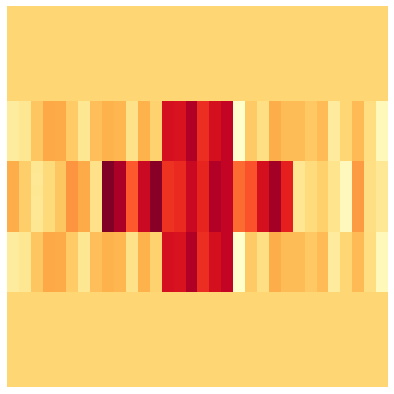

In [10]:
class simple_attached(nn.Module):
    def __init__(self):
        super(simple_attached, self).__init__()
        self.reshape = reshape(split=[1,1,2], map_type=1, device=device)
        self.trl = tltorch.TRL(input_shape=(1,1,2,1,1,size//2), rank=(1,1,2,1,1,10,10), output_shape=(size), bias=False, factorization='tucker')
    def forward(self, x):
        x = x.unsqueeze(dim=1).unsqueeze(dim=2)
        return self.trl(self.reshape(x))
    
model = simple_attached().to(device)

# Train for 10000 epochs
criterion = nn.MSELoss(reduction='mean')
optimizer = optim.Adam(model.parameters())

n_epochs = 10000


for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(x)
    loss = criterion(outputs, y)
    
    loss.backward()
    optimizer.step()

W_attached3 = rearrange(model.trl.weight.to_tensor(), 'a b c d e f g -> g (c f) (b e) (a d)').squeeze()

print(f'This Model has : {count_parameters(model)} parameters')
print(f'RMSE of Train : {np.sqrt(criterion(model(X_train), y_train).item())}')
print(f'RMSE of Test  : {np.sqrt(criterion(model(X_test), y_test).item())}')

fig = plt.figure(figsize=(10,7))
plt.imshow(W_attached3.detach().cpu(), cmap='YlOrRd')
plt.axis('off')
# plt.title(f'attached - trl (10,10) - {count_parameters(model)} #p - RMSE {np.sqrt(criterion(model(X_test), y_test).item()):.3f}', fontsize = 20)
plt.show()


# Basic Compressed Model

This Model has : 58 parameters
RMSE of Train : 2.186261834820863
RMSE of Test  : 2.266158153021456


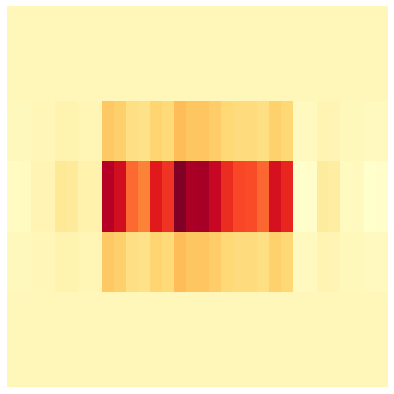

In [11]:
class simple_compressed(nn.Module):
    def __init__(self):
        super(simple_compressed, self).__init__()
        self.reshape = reshape(split=[1,1,2], map_type=2, device=device)
        self.trl = tltorch.TRL(input_shape=(1,1,2,1,1,size//2), rank=(1,1,2,1,1,1,1), output_shape=(size), bias=False, factorization='tucker')
    def forward(self, x):
        x = x.unsqueeze(dim=1).unsqueeze(dim=2)
        return self.trl(self.reshape(x))
    
model = simple_compressed().to(device)

# Train for 10000 epochs
criterion = nn.MSELoss(reduction='mean')
optimizer = optim.Adam(model.parameters())

n_epochs = 10000


for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(x)
    loss = criterion(outputs, y)
    
    loss.backward()
    optimizer.step()

W_compressed1 = rearrange(model.trl.weight.to_tensor(), 'a b c d e f g -> g (f c) (e b) (d a)').squeeze()

print(f'This Model has : {count_parameters(model)} parameters')
print(f'RMSE of Train : {np.sqrt(criterion(model(X_train), y_train).item())}')
print(f'RMSE of Test  : {np.sqrt(criterion(model(X_test), y_test).item())}')

fig = plt.figure(figsize=(10,7))
plt.imshow(W_compressed1.detach().cpu(), cmap='YlOrRd')
plt.axis('off')
# plt.title(f'compressed - trl (1,1) - {count_parameters(model)} #p - RMSE {np.sqrt(criterion(model(X_test), y_test).item()):.3f}', fontsize = 20)
plt.show()


This Model has : 298 parameters
RMSE of Train : 1.5859668898090775
RMSE of Test  : 1.3721453337336034


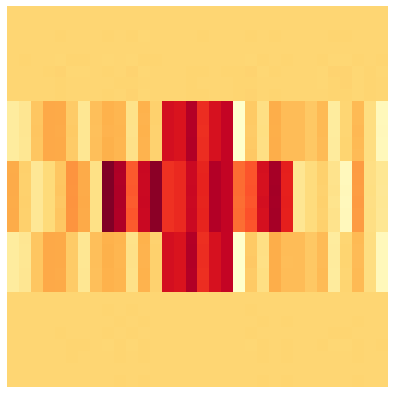

In [12]:
class simple_compressed(nn.Module):
    def __init__(self):
        super(simple_compressed, self).__init__()
        self.reshape = reshape(split=[1,1,2], map_type=2, device=device)
        self.trl = tltorch.TRL(input_shape=(1,1,2,1,1,size//2), rank=(1,1,2,1,1,5,5), output_shape=(size), bias=False, factorization='tucker')
    def forward(self, x):
        x = x.unsqueeze(dim=1).unsqueeze(dim=2)
        return self.trl(self.reshape(x))
    
model = simple_compressed().to(device)

# Train for 10000 epochs
criterion = nn.MSELoss(reduction='mean')
optimizer = optim.Adam(model.parameters())

n_epochs = 10000


for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(x)
    loss = criterion(outputs, y)
    
    loss.backward()
    optimizer.step()

W_compressed2 = rearrange(model.trl.weight.to_tensor(), 'a b c d e f g -> g (f c) (e b) (d a)').squeeze()

print(f'This Model has : {count_parameters(model)} parameters')
print(f'RMSE of Train : {np.sqrt(criterion(model(X_train), y_train).item())}')
print(f'RMSE of Test  : {np.sqrt(criterion(model(X_test), y_test).item())}')

fig = plt.figure(figsize=(10,7))
plt.imshow(W_compressed2.detach().cpu(), cmap='YlOrRd')
plt.axis('off')
# plt.title(f'compressed - trl (5,5) - {count_parameters(model)} #p - RMSE {np.sqrt(criterion(model(X_test), y_test).item()):.3f}', fontsize = 20)
plt.show()


This Model has : 688 parameters
RMSE of Train : 1.5859325390066341
RMSE of Test  : 1.371620185840126


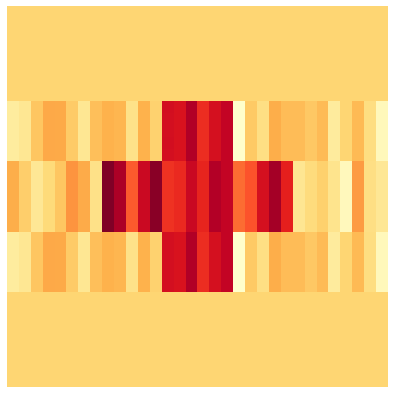

In [13]:
class simple_compressed(nn.Module):
    def __init__(self):
        super(simple_compressed, self).__init__()
        self.reshape = reshape(split=[1,1,2], map_type=2, device=device)
        self.trl = tltorch.TRL(input_shape=(1,1,2,1,1,size//2), rank=(1,1,2,1,1,10,10), output_shape=(size), bias=False, factorization='tucker')
    def forward(self, x):
        x = x.unsqueeze(dim=1).unsqueeze(dim=2)
        return self.trl(self.reshape(x))
    
model = simple_compressed().to(device)

# Train for 10000 epochs
criterion = nn.MSELoss(reduction='mean')
optimizer = optim.Adam(model.parameters())

n_epochs = 10000


for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(x)
    loss = criterion(outputs, y)
    
    loss.backward()
    optimizer.step()

W_compressed3 = rearrange(model.trl.weight.to_tensor(), 'a b c d e f g -> g (f c) (e b) (d a)').squeeze()

print(f'This Model has : {count_parameters(model)} parameters')
print(f'RMSE of Train : {np.sqrt(criterion(model(X_train), y_train).item())}')
print(f'RMSE of Test  : {np.sqrt(criterion(model(X_test), y_test).item())}')

fig = plt.figure(figsize=(10,7))
plt.imshow(W_compressed3.detach().cpu(), cmap='YlOrRd')
plt.axis('off')
# plt.title(f'compressed - trl (10,10) - {count_parameters(model)} #p - RMSE {np.sqrt(criterion(model(X_test), y_test).item()):.3f}', fontsize = 20)
plt.show()
